# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---
### Tutorial: Image Classification with Neural Networks (using Keras Sequential Model)

---

### Dataset: Fashion MNIST Dataset  

- **70,000 grayscale images** of clothing items from 10 categories.  
- Already preprocessed: each image is a 28 × 28 pixel matrix (values between 0–255).  
- The dataset is split into:  
  - **Training set:** 60,000 images  
  - **Test set:** 10,000 images  
- **Labels:** represent 10 clothing categories.  

| Label | Category     |
|:------:|:-------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Each image corresponds to one of these categories.  
Our task is to train a neural network that can correctly classify unseen images.  


**Reference:** This code is based on DeepLearning.AI
1) https://github.com/https-deeplearning-ai/tensorflow-1-public/blob/main/C1/W2/ungraded_labs/C1_W2_Lab_1_beyond_hello_world.ipynb
2) https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb


#### **Step 1: Load and Explore the dataset**

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10

# # Load the dataset
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


In [ ]:
# shape of the train and test datasets

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


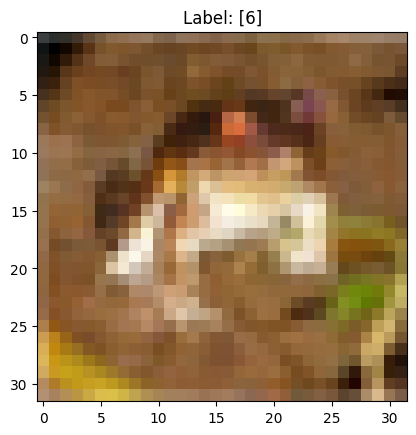

In [ ]:
# Visualize one example
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.title(f'Label: {y_train[0]}')
plt.show()

In [ ]:
#Flatten
y_train = y_train.flatten()

y_test = y_test.flatten()

LABEL: 3

IMAGE PIXEL ARRAY:

[[[125 125 116]
  [110 101  91]
  [102  90  83]
  ...
  [202 207 214]
  [200 205 212]
  [202 208 214]]

 [[142 146 142]
  [146 144 139]
  [176 172 170]
  ...
  [195 201 205]
  [198 205 209]
  [204 211 215]]

 [[180 185 183]
  [143 146 146]
  [156 157 157]
  ...
  [122 111 113]
  [139 128 131]
  [158 147 150]]

 ...

 [[104  82  41]
  [101  80  39]
  [101  81  38]
  ...
  [126 103  67]
  [126 103  69]
  [125 101  68]]

 [[104  81  40]
  [105  84  41]
  [109  88  43]
  ...
  [138 113  78]
  [137 113  80]
  [137 112  81]]

 [[105  83  42]
  [108  87  45]
  [115  94  50]
  ...
  [143 117  82]
  [143 116  84]
  [144 116  86]]]




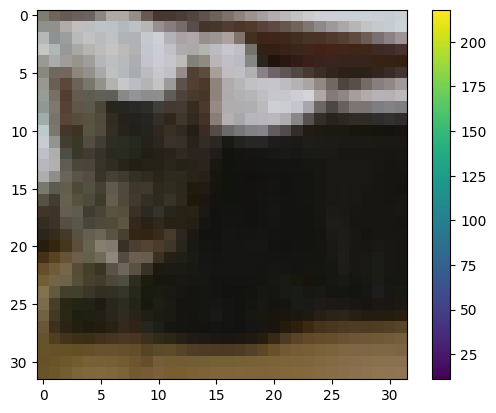

In [ ]:
#Let's explore pixel values

# You can put between 0 to 59999 here
index = 9 # you’re choosing the 10th image (since indexing starts at 0)

# Set number of characters per row when printing
np.set_printoptions(linewidth=300)

# Print the label and image
print(f'LABEL: {y_train[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n\n{x_train[index]}\n\n') # 2D array representing the pixel values of the selected image, where each element in the array corresponds to the brightness of a pixel (0-255)

# Visualize the image using the default colormap (viridis)
plt.imshow(x_train[index])
plt.colorbar()
plt.show()


#### **Step 2: Normalize the Data**

Neural networks perform best when inputs are on a similar scale.
We divide pixel values by 255 so all values fall between 0 and 1.

In [ ]:
# Values in the image data range from 0 to 255. For better neural network performance,  scale these values to between 0 and 1.

x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0


#### **Step 3: Model Building and Compilation**

Now that the data is prepared, let’s build a simple **neural network model** using the Keras Sequential API.  
This model will learn to classify the Fashion MNIST images into one of the ten clothing categories.  

---

**Build a Sequential model with:**
- **Input**: 28×28 grayscale image  
- **Flatten layer**: convert image to a 1D vector (784 features)
- **Hidden layer**: 128 units, ReLU activation
- **Output layer**: 10 units, Softmax activation (one per class)

**Compile the Model:**
- **Optimizer**: adam (adaptive learning rate; strong default choice)
- **Loss**: sparse_categorical_crossentropy - Used when class labels are integers (0–9)
- **Metric**: accuracy

---


### **Exercise 1:👉 Fill in the missing arguments.

In [ ]:
from tensorflow.keras import models, layers, Input

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Flatten(),      # Flatten 28x28 image to 1D vector
    layers.Dense(128, activation='relu'),    # Hidden layer with ReLU activation 👈 Fill in the blanks
    layers.Dense(10, activation='softmax')     # Output layer for 10 categories 👈 Fill in the blanks
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

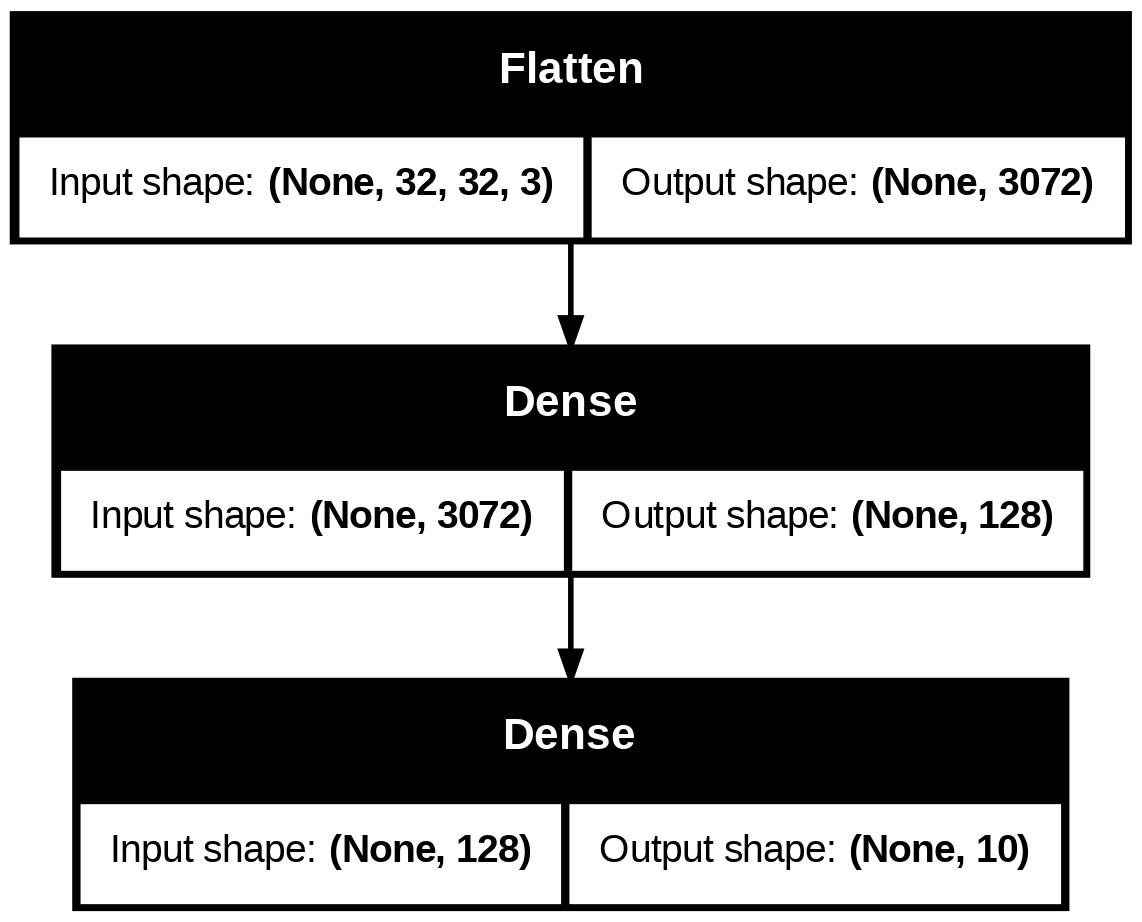

In [ ]:
# display model architecture
tf.keras.utils.plot_model(model, show_shapes=True)

👉 Fill in the missing arguments.

In [ ]:

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # 👈 Fill in the blanks



#### **Step 4: Training and Evaluating the Model**

Now that the model is built and compiled, we can begin **training** — the process where the network learns from the data by adjusting its internal weights to minimize error.

During training, the model iteratively improves its predictions using **forward** and **backward propagation** over several *epochs*.

---

**Key Terms**

- **Epoch:** One complete pass through the entire training dataset.  
- **Batch size:** Number of samples processed before the model updates its weights.  
- **Validation split:** Portion of training data set aside to monitor how well the model generalizes (helps detect overfitting).

---

**Training Parameters:**

- Epochs → `10`  
- Batch size → `128`  
- Validation split → `0.2` (20% of training data used for validation)

---

By experimenting with these parameters, we can observe how they affect training speed and accuracy.  
For instance, smaller batches can provide more frequent updates (but take longer), while larger batches train faster but may converge less smoothly.



### **Exercise 2: 👉 Fill in the missing arguments.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2289 - loss: 2.2074 - val_accuracy: 0.3369 - val_loss: 1.8712
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3500 - loss: 1.8329 - val_accuracy: 0.3537 - val_loss: 1.8421
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3755 - loss: 1.7755 - val_accuracy: 0.3842 - val_loss: 1.7609
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3802 - loss: 1.7521 - val_accuracy: 0.3723 - val_loss: 1.7767
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3951 - loss: 1.7161 - val_accuracy: 0.3838 - val_loss: 1.7543
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4013 - loss: 1.6998 - val_accuracy: 0.3903 - val_loss: 1.7381
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4049 - loss: 1.6861 - val_accuracy: 0.3915 - val_loss: 1.7230
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4116 - loss: 1.6712 - val_accu

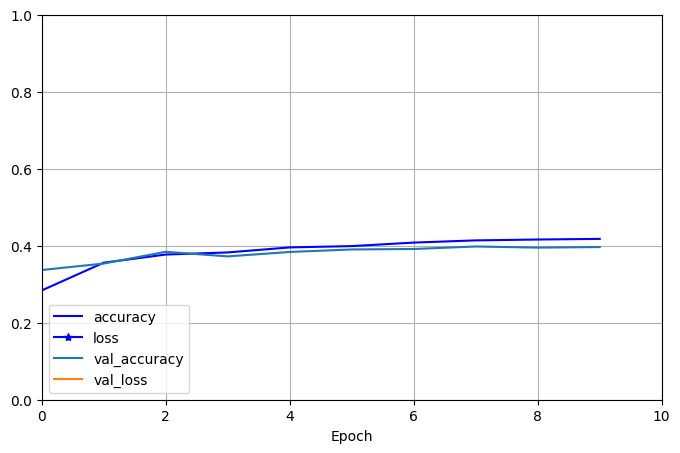

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["b-", "b-*"])
plt.legend(loc="lower left")
plt.show()

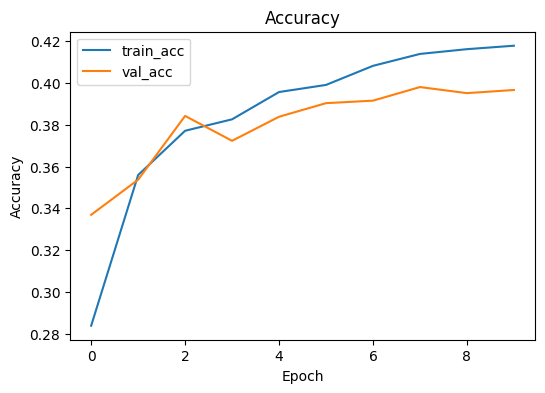

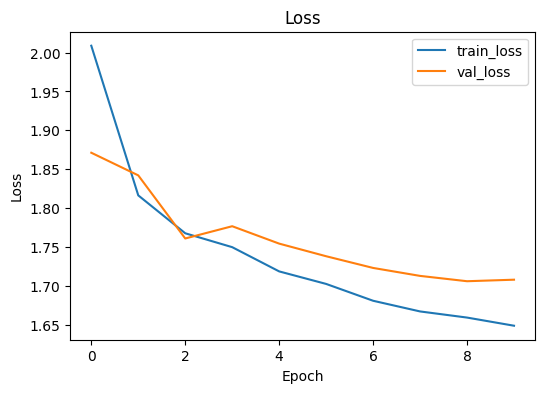

In [ ]:
# Accuracy (train and val)  and Loss (train and val) plots
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")
plt.show()

In [ ]:
# Evaluate the model on unseen data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.2f}, Test Loss: {test_loss:.2f}")

313/313 - 1s - 3ms/step - accuracy: 0.4009 - loss: 1.6825
Test Accuracy: 0.40, Test Loss: 1.68


### **Exercise 3: Model Building**


1. **What happen if you remove the Flatten() Layer?**  
   - Once you complete running the entire notebook, re-run the notebook after removing Flatten() and observe the behavior.  
2. **What happen if you set the output layer to 5 categories?**  





### **Step 5: Make Predictions**

Now that our model is trained, we can use it to **make predictions** on unseen test data.  
Here, we’ll take **samples 10–20 from the test dataset** and compare the predicted labels with the actual labels.

---

#### **Understanding the Process**

1. **Model Predictions (`y_proba`)** – The model outputs a probability for each of the 10 classes.  
   - For example, a value of ` [0.232, 0.   , 0.091, 0.043, 0.017, 0.   , 0.616, 0.   , 0.001, 0.   ]` means the model believes class 6 (with 0.616 probability) is most likely.  
2. **Predicted Class (`y_pred`)** – We use `argmax()` to pick the class with the highest probability.  
3. **True Class (`y_new`)** – The correct label from the test data.  
4. **Class Names** – are the labels like “Sneaker” or “Dress”.

---



In [ ]:
# Let's use the first five records of the training dataset
X_new = x_test[10:20]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.16, 0.01, 0.03, 0.02, 0.01, 0.01, 0.01, 0.  , 0.72, 0.02],
       [0.01, 0.14, 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.03, 0.8 ],
       [0.01, 0.04, 0.09, 0.2 , 0.08, 0.24, 0.26, 0.03, 0.04, 0.01],
       [0.12, 0.07, 0.1 , 0.11, 0.07, 0.11, 0.13, 0.12, 0.11, 0.07],
       [0.11, 0.26, 0.03, 0.03, 0.01, 0.02, 0.01, 0.1 , 0.11, 0.31],
       [0.1 , 0.01, 0.09, 0.03, 0.16, 0.05, 0.04, 0.04, 0.47, 0.01],
       [0.05, 0.01, 0.04, 0.29, 0.01, 0.31, 0.07, 0.19, 0.03, 0.  ],
       [0.12, 0.01, 0.06, 0.16, 0.1 , 0.07, 0.13, 0.2 , 0.07, 0.06],
       [0.01, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.87, 0.1 ],
       [0.01, 0.02, 0.03, 0.11, 0.07, 0.06, 0.6 , 0.07, 0.01, 0.03]], dtype=float32)

In [ ]:
# Predicted classes
y_pred = y_proba.argmax(axis=-1)
y_pred

array([8, 9, 6, 6, 9, 8, 5, 7, 8, 6])

In [ ]:
# Actual Classes
y_new = y_test[10:20]
y_new

array([0, 9, 5, 7, 9, 8, 5, 7, 8, 6], dtype=uint8)

In [ ]:
# Let's print class names
class_names =   ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

np.array(class_names)[y_pred]

array(['ship', 'truck', 'frog', 'frog', 'truck', 'ship', 'dog', 'horse', 'ship', 'frog'], dtype='<U10')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


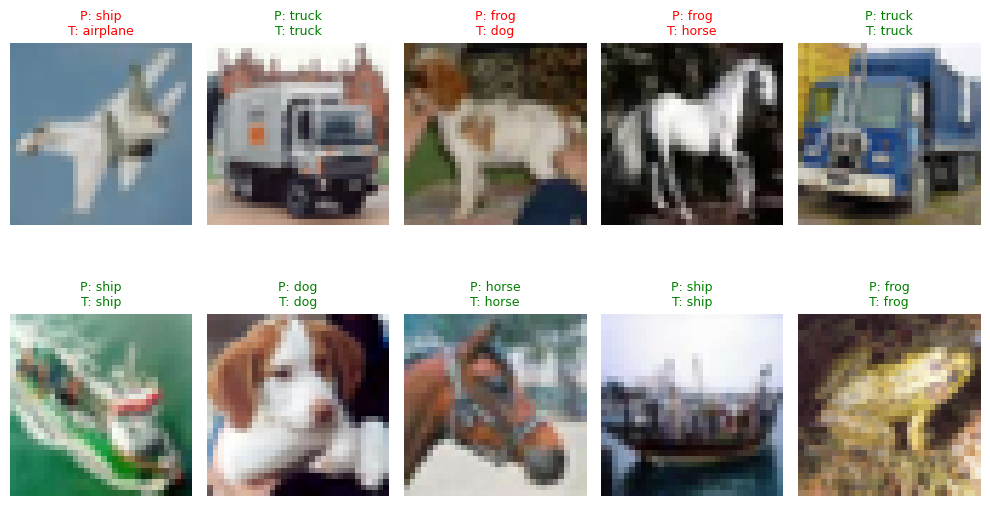

In [38]:
# Let's visualize the predictions


import numpy as np
import matplotlib.pyplot as plt

# Generate predictions for test set
predictions = model.predict(x_test)


start, end = 10, 20  # 👈 Change the values here based on the range

plt.figure(figsize=(10, 6))
for idx, i in enumerate(range(start, end)):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_test[i])
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P: {class_names[pred_label]}\nT: {class_names[true_label]}", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Exercise 4: Investigate Model Predictions**


1. **Does the model predict all 10 classes correctly?**  
   - Review the predicted class names and see if any category is consistently missing or misclassified.  
2. **Change the sample range** in the code (e.g., `x_test[0:10]`, `x_test[100:110]`) and **rerun the predictions.**  
   - Do you notice any changes in the outcomes?  
3. **Reflect on your findings:**  
   - What types of clothing are most frequently confused?  
   - What strategies could improve its performance?

